# Circuits And Compilers

This notebook compares concrete circuit tooling and compiler roles.

Corpus anchors: `PRIM5`, `PRIM6`, `PRIM8`, `PRIM14`, `PRIM15`, `PRIM16`; route gates `IO4`, `IO5`, `IO7`, `IO8`.

Compact object: a two-qubit Bell-state primitive as the smallest visual circuit sanity check.


tooling atlas output directory: .cache\tooling_atlas


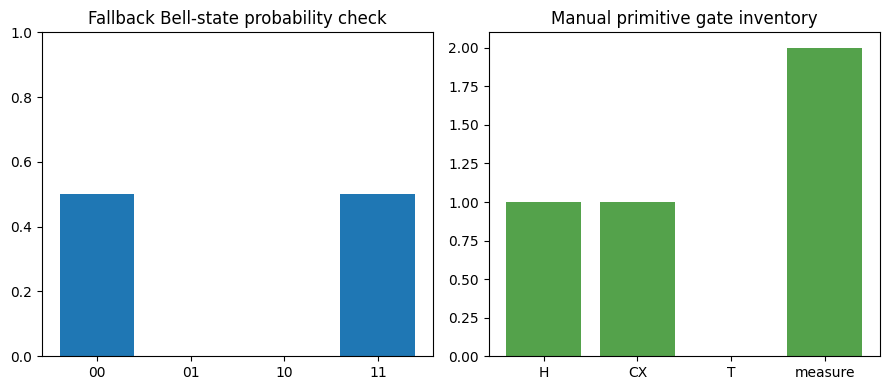

falsifiable check: fallback Bell primitive produces only |00> and |11> outcomes


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

# Fallback live circuit check with NumPy, so the notebook executes without promoting a circuit SDK.
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
I = np.eye(2, dtype=complex)
CNOT = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
], dtype=complex)
zero_zero = np.array([1, 0, 0, 0], dtype=complex)
state = CNOT @ np.kron(H, I) @ zero_zero
probabilities = np.abs(state) ** 2

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(['00', '01', '10', '11'], probabilities)
axes[0].set_ylim(0, 1)
axes[0].set_title('Fallback Bell-state probability check')
manual_counts = {'H': 1, 'CX': 1, 'T': 0, 'measure': 2}
axes[1].bar(manual_counts.keys(), manual_counts.values(), color='#54a24b')
axes[1].set_title('Manual primitive gate inventory')
plt.tight_layout()
plt.show()

assert np.allclose(probabilities, [0.5, 0.0, 0.0, 0.5])
print('falsifiable check: fallback Bell primitive produces only |00> and |11> outcomes')


In [2]:
# Sandbox package inventory: generated from .cache/tooling_atlas/installed_packages_report.json.
from pathlib import Path
import json

report_path = Path('.cache/tooling_atlas/installed_packages_report.json')
if report_path.exists():
    report = json.loads(report_path.read_text(encoding='utf-8'))
    rows = []
    for env_name, env in report.items():
        for package, info in env['packages'].items():
            rows.append({
                'env': env_name,
                'package': package,
                'version': info.get('version') or '',
                'import': 'ok' if info.get('import_ok') else 'blocked',
                'note': info.get('error') or '',
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(f"{row['env']:12s} {row['package']:16s} {row['version']:10s} {row['import']:8s} {row['note']}")
else:
    print('No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.')

No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.


In [3]:
# Optional circuit/compile tool demos. These should run only when the sandbox package is installed.
packages = ['qiskit', 'cirq', 'cudaq', 'pytket', 'bqskit', 'pyzx', 'mqt.qmap']
print({pkg: has_module(pkg) for pkg in packages})

if has_module('qiskit'):
    try:
        from qiskit import QuantumCircuit, transpile
        qc = QuantumCircuit(2)
        qc.h(0)
        qc.cx(0, 1)
        tqc = transpile(qc, basis_gates=['h', 'cx'], optimization_level=0)
        print('Qiskit live demo count_ops:', dict(tqc.count_ops()))
    except Exception as exc:
        print('Qiskit demo failed:', type(exc).__name__, exc)
else:
    print('Qiskit sandbox not installed; use .cache/tooling_atlas/ if we choose that trial.')

if has_module('cirq'):
    try:
        import cirq
        q0, q1 = cirq.LineQubit.range(2)
        circuit = cirq.Circuit(cirq.H(q0), cirq.CNOT(q0, q1))
        print('Cirq live demo circuit:')
        print(circuit)
    except Exception as exc:
        print('Cirq demo failed:', type(exc).__name__, exc)


{'qiskit': True, 'cirq': True, 'cudaq': False, 'pytket': True, 'bqskit': True, 'pyzx': False, 'mqt.qmap': True}


Qiskit live demo count_ops: {'h': 1, 'cx': 1}


Cirq live demo circuit:
0: ───H───@───
          │
1: ───────X───


## What This Cannot Prove

A tiny Bell circuit is useful for checking drawing, counting, transpilation, and package ergonomics. It says nothing about QCFD loading, LBM streaming/collision circuits, block encodings, or FTQC-scale resource estimates.
